

# **Step 1 — Mount Google Drive and Set Up Environment**


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/dataset

conversation_data.json


# **Step 2 — Environment Setup & Library Installation**

In [5]:
!pip install tensorflow pandas numpy scikit-learn nltk matplotlib transformers

In [6]:
import pandas as pd
import numpy as np
import json
import os
import re
import nltk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# **Step 3 — Load and Inspect the Dataset**

In [7]:
# Path to your dataset
data_path = "/content/drive/MyDrive/dataset/conversation_data.json"

# Load JSON file
with open(data_path, "r") as f:
    data = json.load(f)

# Check how many records
print("Total conversations:", len(data))

# Display one sample entry
print(json.dumps(data[0], indent=2))

Total conversations: 213
{
  "id": "RES0001",
  "conversation_pairs": [
    {
      "patient": "I so I've just had this pain in my chest for just over a week now and it's caused me to have trouble breathing.",
      "doctor": "OK, um how old are you, Jen?"
    },
    {
      "patient": "Um 52.",
      "doctor": "OK when did this pain start? You said a week back?"
    },
    {
      "patient": "Uh, yeah, just about that I I think maybe 8 days ago.",
      "doctor": "OK, and is it a constant pain? Is it always there?"
    },
    {
      "patient": "Ahh it it is, but it's definitely worse that um, it's the breathing that's been bothering me a lot more. When I take a deep breath that the pain is a lot worse.",
      "doctor": "OK, OK um. And when you do get that, get that pain. How long does it last?"
    },
    {
      "patient": "Um I would say, uh. Around 15-20 minutes. It's it goes away over overtime.",
      "doctor": "OK, and the shortness of breath do you have that at rest as well?"

# **Step 4 — Extract and Flatten Conversations**

In [8]:
all_texts = []
all_speakers = []

for convo in data:
    pairs = convo.get("conversation_pairs", [])
    for pair in pairs:
        # each pair has a patient line and a doctor line
        if "patient" in pair:
            all_texts.append(pair["patient"])
            all_speakers.append("patient")
        if "doctor" in pair:
            all_texts.append(pair["doctor"])
            all_speakers.append("doctor")

df = pd.DataFrame({"text": all_texts, "speaker": all_speakers})
print("Total utterances:", len(df))
df.head(10)

Total utterances: 19916


,text,speaker
0,I so I've just had this pain in my chest for j...,patient
1,"OK, um how old are you, Jen?",doctor
2,Um 52.,patient
3,OK when did this pain start? You said a week b...,doctor
4,"Uh, yeah, just about that I I think maybe 8 da...",patient
5,"OK, and is it a constant pain? Is it always th...",doctor
6,"Ahh it it is, but it's definitely worse that u...",patient
7,"OK, OK um. And when you do get that, get that ...",doctor
8,"Um I would say, uh. Around 15-20 minutes. It's...",patient
9,"OK, and the shortness of breath do you have th...",doctor


# **Step 5 — Data Cleaning & Preprocessing**



In [9]:
import re
import string
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove filler words
    text = re.sub(r'\b(um+|uh+|ah+|er+|hmm+)\b', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("Sample cleaned text:")
df.head(10)[['text', 'clean_text']]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sample cleaned text:


,text,clean_text
0,I so I've just had this pain in my chest for j...,i so ive just had this pain in my chest for ju...
1,"OK, um how old are you, Jen?",ok how old are you jen
2,Um 52.,52
3,OK when did this pain start? You said a week b...,ok when did this pain start you said a week back
4,"Uh, yeah, just about that I I think maybe 8 da...",yeah just about that i i think maybe 8 days ago
5,"OK, and is it a constant pain? Is it always th...",ok and is it a constant pain is it always there
6,"Ahh it it is, but it's definitely worse that u...",it it is but its definitely worse that its the...
7,"OK, OK um. And when you do get that, get that ...",ok ok and when you do get that get that pain h...
8,"Um I would say, uh. Around 15-20 minutes. It's...",i would say around 1520 minutes its it goes aw...
9,"OK, and the shortness of breath do you have th...",ok and the shortness of breath do you have tha...


# **Step 6 — Tokenization and Sequence Preparation**

In [10]:
# Prepare tokenizer
MAX_VOCAB_SIZE = 10000  # adjust if needed
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Padding to make all sequences equal length
MAX_SEQ_LENGTH = 30  # typical for short utterances; tune if needed
X = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

# Encode speaker labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['speaker'])
y = to_categorical(y)

print("Vocabulary size:", len(tokenizer.word_index))
print("Example sequence:", sequences[0])
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Vocabulary size: 4310
Example sequence: [2, 18, 45, 21, 23, 41, 63, 19, 31, 102, 27, 21, 95, 10, 151, 66, 3, 25, 603, 110, 15, 13, 490, 170]
Shape of X: (19916, 30)
Shape of y: (19916, 2)


# **Step 7 — Train-Test Split & Basic Data Check**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)

Training samples: (15932, 30)
Validation samples: (3984, 30)


# **Step 8 — Data Augmentation**

In [12]:
import random
import pandas as pd
import nltk
from nltk.corpus import wordnet

# Make sure WordNet is downloaded
nltk.download('wordnet')
nltk.download('omw-1.4')

# Augmentation function
def synonym_replace(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = [word for word in words if wordnet.synsets(word)]
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            if synonym != random_word:
                new_words = [synonym if word == random_word else word for word in new_words]
                num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

# Apply to 30% of data randomly to avoid overfitting
sample_fraction = 0.3
aug_df = df.sample(frac=sample_fraction, random_state=42).copy()

aug_df["clean_text"] = aug_df["clean_text"].apply(lambda x: synonym_replace(x, n=1))

# Merge with original dataset
expanded_df = pd.concat([df, aug_df]).reset_index(drop=True)

print(f"Original samples: {len(df)}")
print(f"Augmented samples: {len(aug_df)}")
print(f"Total after augmentation: {len(expanded_df)}")

# Quick check
print("\nSample before & after augmentation:")
print(df.iloc[0]['clean_text'])
print("→", expanded_df.iloc[-1]['clean_text'])


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Original samples: 19916
Augmented samples: 5975
Total after augmentation: 25891

Sample before & after augmentation:
i so ive just had this pain in my chest for just over a week now and its caused me to have trouble breathing
→ okay rich_person you been around anyone thats sick recently


In [13]:
import random
import pandas as pd
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('omw-1.4')

def synonym_replace(sentence, n=2):
    words = sentence.split()
    if len(words) < 2:
        return sentence
    new_words = words.copy()
    random_word_list = [word for word in words if wordnet.synsets(word)]
    if not random_word_list:
        return sentence
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            if synonym != random_word:
                new_words = [synonym if word == random_word else word for word in new_words]
                num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def random_insertion(sentence, n=1):
    words = sentence.split()
    if len(words) < 1:
        return sentence
    for _ in range(n):
        add_word = random.choice(words)
        pos = random.randint(0, len(words))
        words.insert(pos, add_word)
    return ' '.join(words)

def random_deletion(sentence, p=0.1):
    words = sentence.split()
    if len(words) <= 1:
        return sentence
    new_words = [word for word in words if random.uniform(0, 1) > p]
    if len(new_words) == 0:
        return random.choice(words)
    return ' '.join(new_words)

def augment_text(sentence):
    if not isinstance(sentence, str) or sentence.strip() == "":
        return sentence
    choice = random.choice(['synonym', 'insert', 'delete'])
    if choice == 'synonym':
        return synonym_replace(sentence, n=1)
    elif choice == 'insert':
        return random_insertion(sentence, n=1)
    elif choice == 'delete':
        return random_deletion(sentence, p=0.15)
    return sentence

# Use the latest dataset
base_df = expanded_df.copy()  # instead of df

sample_fraction = 0.4
aug_df = base_df.sample(frac=sample_fraction, random_state=42).copy()

aug_df["clean_text"] = aug_df["clean_text"].apply(augment_text)

# Merge with original + shuffle
expanded_df = pd.concat([base_df, aug_df]).drop_duplicates(subset=['clean_text']).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original samples: {len(base_df)}")
print(f"Augmented samples: {len(aug_df)}")
print(f"Total after augmentation: {len(expanded_df)}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Original samples: 25891
Augmented samples: 10356
Total after augmentation: 27245


# **Step 9 — Build the LSTM Speaker Segmentation Model**

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Parameters
vocab_size = 5000          # from tokenizer earlier
embedding_dim = 128
lstm_units = 128
max_sequence_len = 30       # as we padded before
num_classes = 2             # doctor/patient

# Build model
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_sequence_len),
    Bidirectional(LSTM(lstm_units, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Step 10 — Training Hyperparameters & Regularization (pre-training setup)**

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Hyperparameters
EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4  # small L2 regularization

# Re-compile model with regularization (optional fine-tune)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

checkpoint_path = "/content/drive/MyDrive/doctor_patient_lstm/best_model.keras"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
model_ckpt = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("✅ Hyperparameters & callbacks set — ready to start training next.")

✅ Hyperparameters & callbacks set — ready to start training next.


# **Step 11 — Train the Model**

In [16]:
# Make sure X_train, X_val, y_train, y_val exist
print("Training data shape:", X_train.shape, y_train.shape)
print("Validation data shape:", X_val.shape, y_val.shape)

# Train
history = model.fit(
    X_train,
    np.argmax(y_train, axis=1),   # converting one-hot back to class indices
    validation_data=(X_val, np.argmax(y_val, axis=1)),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, model_ckpt],
    verbose=1
)

# Save final model (optional)
final_model_path = "/content/drive/MyDrive/doctor_patient_lstm/final_model.keras"
model.save(final_model_path)
print(f"✅ Model training complete. Saved at: {final_model_path}")


Training data shape: (15932, 30) (15932, 2)
Validation data shape: (3984, 30) (3984, 2)
Epoch 1/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8982 - loss: 0.2280
Epoch 1: val_accuracy improved from -inf to 0.97214, saving model to /content/drive/MyDrive/doctor_patient_lstm/best_model.keras
498/498 ━━━━━━━━━━━━━━━━━━━━ 118s 201ms/step - accuracy: 0.8983 - loss: 0.2278 - val_accuracy: 0.9721 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 2/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9745 - loss: 0.0681
Epoch 2: val_accuracy improved from 0.97214 to 0.97515, saving model to /content/drive/MyDrive/doctor_patient_lstm/best_model.keras
498/498 ━━━━━━━━━━━━━━━━━━━━ 94s 189ms/step - accuracy: 0.9745 - loss: 0.0681 - val_accuracy: 0.9752 - val_loss: 0.0721 - learning_rate: 0.0010
Epoch 3/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9804 - loss: 0.0528
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy

# **Step 12 — Plot Training Curves**

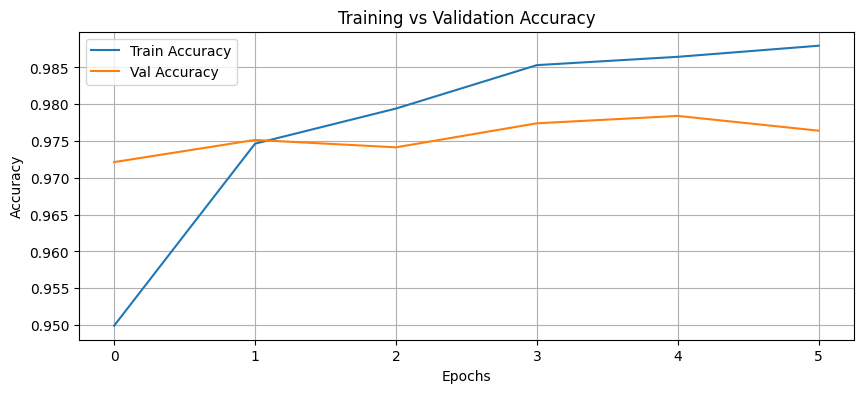

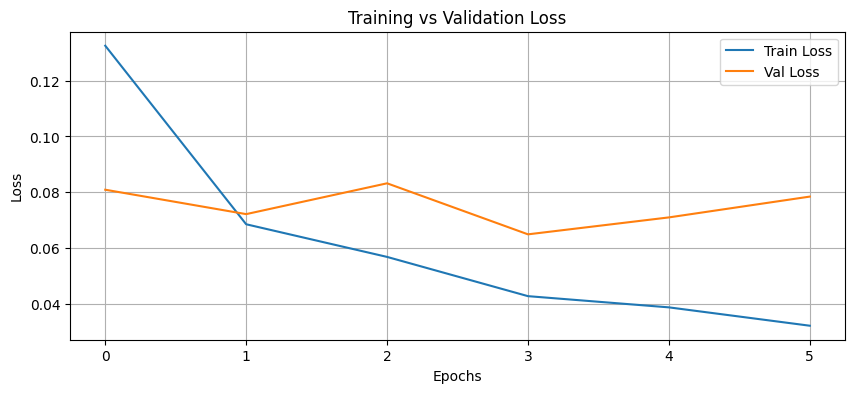

In [17]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# **Step 13 — Plot Training Curves**

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
Classification report:
              precision    recall  f1-score   support

      doctor       0.98      0.98      0.98      1991
     patient       0.98      0.98      0.98      1993

    accuracy                           0.98      3984
   macro avg       0.98      0.98      0.98      3984
weighted avg       0.98      0.98      0.98      3984



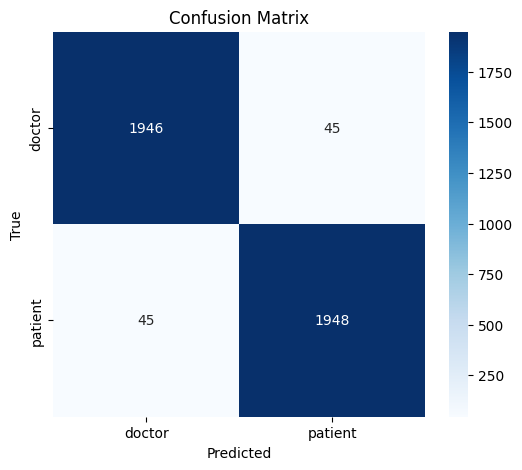

Total misclassified: 90 / 3984
----
Text: and was she born what weight was she when she was born <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
True: doctor
Pred: patient

----
Text: it was full time and it was vaginal <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
True: patient
Pred: doctor

----
Text: no no blood in the stool right <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
True: doctor
Pred: patient

----
Text: no chest pain <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
True: doctor
Pred: patient

----
Text: do you think this is like an urgent matter <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>

In [18]:
# === Final evaluation & error analysis ===
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# If you have a separate test set, replace X_test_pad/y_test below.
# Otherwise we'll use X_val / y_val as test
X_test = X_val      # or your test split
y_test = y_val

# Predict
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Error analysis: show common misclassifications
# we need original texts corresponding to X_test (we used texts earlier before tokenization)
# Reconstruct mapping from padded sequences to original cleaned_sentences if available.
# If you still have X_val texts (strings), use them. Example below assumes you have X_val_texts list.

try:
    # if X_val_texts exists (texts prior to tokenization)
    X_test_texts = X_val_texts
except NameError:
    # attempt to reconstruct: if you still have tokenizer and original expanded_df split mapping
    # otherwise this will fallback to a sequence-to-text decode which is rough
    X_test_texts = tokenizer.sequences_to_texts(X_test)

# collect misclassified examples
mis_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(mis_idx)} / {len(y_true)}")

# show top 20 misclassified
for i in mis_idx[:20]:
    print("----")
    print("Text:", X_test_texts[i])
    print("True:", label_encoder.inverse_transform([y_true[i]])[0])
    print("Pred:", label_encoder.inverse_transform([y_pred[i]])[0])
    print()

# **Step 14 - Saving Model**


In [24]:
import os, pickle, json
from tensorflow.keras.models import save_model

# Directory in Drive
artifact_dir = "/content/drive/MyDrive/doctor_patient_lstm/"
os.makedirs(artifact_dir, exist_ok=True)

# --- 1️⃣ Save Model ---
model.save(os.path.join(artifact_dir, "speaker_lstm.keras"))  # modern format
print("✅ Model saved as speaker_lstm.keras")

# --- 2️⃣ Save Tokenizer (JSON or Pickle, both okay) ---
# Preferred: JSON (portable, framework-agnostic)
tokenizer_json = tokenizer.to_json()
with open(os.path.join(artifact_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer_json)
print("✅ Tokenizer saved as tokenizer.json")

# --- 3️⃣ Save Label Encoder ---
with open(os.path.join(artifact_dir, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved as label_encoder.pkl")

print("📁 Saved files:", os.listdir(artifact_dir))


✅ Model saved as speaker_lstm.keras
✅ Tokenizer saved as tokenizer.json
✅ Label encoder saved as label_encoder.pkl
📁 Saved files: ['best_model.keras', 'final_model.keras', 'speaker_lstm.keras', 'tokenizer.pkl', 'label_encoder.pkl', 'tokenizer.json']


In [25]:
import pickle, json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json

artifact_dir = "/content/drive/MyDrive/doctor_patient_lstm/"

# --- 1️⃣ Load model ---
model = load_model(os.path.join(artifact_dir, "speaker_lstm.keras"))

# --- 2️⃣ Load tokenizer ---
with open(os.path.join(artifact_dir, "tokenizer.json"), "r", encoding="utf-8") as f:
    tokenizer = tokenizer_from_json(f.read())

# --- 3️⃣ Load label encoder ---
with open(os.path.join(artifact_dir, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

print("✅ Model, tokenizer, and label encoder reloaded successfully!")


✅ Model, tokenizer, and label encoder reloaded successfully!
